In [30]:
%matplotlib notebook

import matplotlib.pyplot as plt
import pickle
import numpy as np
from glob import glob
from pandas import DataFrame
from pprint import pprint

In [5]:
all_pkls = glob('../auto_config/configs/mysql_random_config/*.pkl')
result_pkls = list(filter(lambda x: 'result' in x, all_pkls))

In [7]:
pkl = result_pkls[0]

In [209]:
len(config)

18

In [36]:
df = DataFrame()
data = []
for pkl in result_pkls:
    with open(pkl, 'rb') as f:
        a = pickle.load(f)

    status_set = set()
    for q_id, q_result in a['raw_times'].items():
        status_set.add(q_result['status'])
    if len(status_set) != 1 or len(a['raw_times']) < 22:
        continue
        
#     pprint(a)
#     break
    
    df = df.append({'run_time':a['run_time'],
                   }, ignore_index=True)
    
    # featurize
    config = a['config']
    flush_method = config.pop('innodb_flush_method', None)
    innodb_flush_methods = ["fsync", "O_DSYNC", "littlesync", "nosync", "O_DIRECT", "O_DIRECT_NO_FSYNC",]
    method_index = innodb_flush_methods.index(flush_method)
        
    x = np.zeros(len(config) + len(innodb_flush_methods) )
    
    for i, k in enumerate(sorted(config.keys())):
        x[i] = config[k]
    
    # one-hot encoding
    x[len(config) + method_index] = 1.
    
    y = np.zeros(23)  # 22 single query result + total benchmark
    for q_result in a['raw_times'].values():
        query_idx = q_result['q_type']  # 1-22
        y[query_idx] = q_result['query_run_time']
    
    y[0] = a['run_time']
    
    data.append((x, y))

In [65]:
len(data[0][0])

24

In [67]:
Xs, Ys = np.zeros(( len(data), len(data[0][0])) ), np.zeros((len(data), 23))
for i, (x, y) in enumerate(data):
    Xs[i, :] = x
    Ys[i, :] = y
data = (Xs, Ys)

<IPython.core.display.Javascript object>


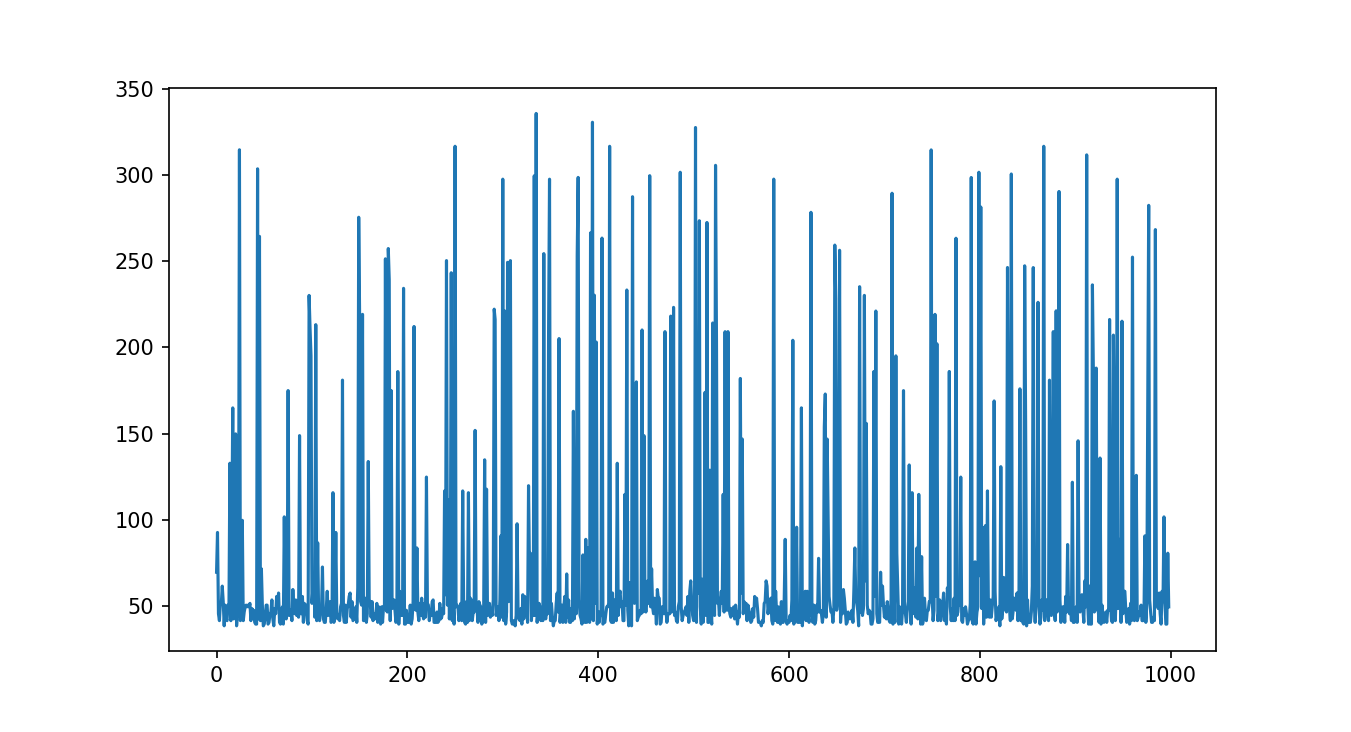

In [24]:
plt.plot(df)

In [124]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso

import GPy
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

import torch
from torch.autograd import Variable
import torch.nn.functional as F
import torch.utils.data as Data

In [91]:
def split_data(data, data_size):
    Xs, Ys = data
    
    # train, valid, test = [], [], []
    train = Xs[:data_size], Ys[:data_size]
    valid = Xs[data_size:int(data_size*1.1)], Ys[data_size:int(data_size*1.1)]
    test = Xs[-200:], Ys[-200:]
    return train, valid, test

In [201]:
def shuffle_data(data):
    Xs, Ys = data
    n_samples, _ = Xs.shape
    a = np.arange(n_samples)
    random.shuffle(a)
    new_Xs = Xs[a, :]
    new_Ys = Ys[a, :]
    return (new_Xs, new_Ys)

In [205]:
data_sizes = [30, 50, 100, 200, 300, 400, 500, 600, 700, 800]
df = DataFrame()

for trial in range(5):
    data = shuffle_data(data)
    for data_size in data_sizes:
        train, valid, test = split_data(data, data_size)

        model_errors = {'data_size': data_size, 'trial':trial}

        model_errors['linear'] = fit_linear_model(train, valid, test)
        model_errors['gpr'] = fit_gpr_model(train, valid, test)
        model_errors['nn'] = fit_nn_model(train, valid, test)
        for alpha in [0., 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.5, 0.8, 1., 2., 4., 5., 8., 10.]:
            model_errors[f'nn_multi alpha={alpha}'] = fit_nn_multi_model(train, valid, test, alpha)

        print(model_errors)
        df = df.append(model_errors, ignore_index=True)
df

{'data_size': 30, 'trial': 0, 'linear': 5709.463378282928, 'gpr': 1890.5992677852762, 'nn': 2364.41720603204, 'nn_multi alpha=0.0': 2558.0736258527495, 'nn_multi alpha=0.01': 3563.5009574045353, 'nn_multi alpha=0.02': 2403.8341237158425, 'nn_multi alpha=0.05': 3547.100998385778, 'nn_multi alpha=0.1': 2492.837384841803, 'nn_multi alpha=0.2': 2159.081856421227, 'nn_multi alpha=0.4': 1887.2150511140644, 'nn_multi alpha=0.5': 2563.471967778418, 'nn_multi alpha=0.8': 2771.993088746334, 'nn_multi alpha=1.0': 3099.8999947674897, 'nn_multi alpha=2.0': 2683.7070802102917, 'nn_multi alpha=4.0': 2872.263696498842, 'nn_multi alpha=5.0': 2280.559432603969, 'nn_multi alpha=8.0': 3057.1392043120704, 'nn_multi alpha=10.0': 2502.050441356221}
{'data_size': 50, 'trial': 0, 'linear': 2115.332524633716, 'gpr': 1573.6165720488573, 'nn': 2171.7398542403807, 'nn_multi alpha=0.0': 2153.77711611698, 'nn_multi alpha=0.01': 1701.4685332454173, 'nn_multi alpha=0.02': 1922.2532175186318, 'nn_multi alpha=0.05': 190

{'data_size': 100, 'trial': 1, 'linear': 2073.9668035619225, 'gpr': 1490.8107120595012, 'nn': 2779.1812110704236, 'nn_multi alpha=0.0': 2753.369232842169, 'nn_multi alpha=0.01': 3197.176694241556, 'nn_multi alpha=0.02': 1106.1536054444723, 'nn_multi alpha=0.05': 3148.344785653369, 'nn_multi alpha=0.1': 2843.193103315208, 'nn_multi alpha=0.2': 1332.630261657122, 'nn_multi alpha=0.4': 2603.136060542871, 'nn_multi alpha=0.5': 2196.9115901064, 'nn_multi alpha=0.8': 3161.9098287027923, 'nn_multi alpha=1.0': 3244.3175304311544, 'nn_multi alpha=2.0': 3198.343814193936, 'nn_multi alpha=4.0': 3110.1044376365257, 'nn_multi alpha=5.0': 3043.161263791381, 'nn_multi alpha=8.0': 3285.0228792053213, 'nn_multi alpha=10.0': 2799.433837884771}
{'data_size': 200, 'trial': 1, 'linear': 1915.6434379241693, 'gpr': 951.990666678558, 'nn': 3696.9077490747686, 'nn_multi alpha=0.0': 3597.425370414242, 'nn_multi alpha=0.01': 3475.4771337492393, 'nn_multi alpha=0.02': 4573.285698405757, 'nn_multi alpha=0.05': 445

{'data_size': 300, 'trial': 2, 'linear': 2060.956793545853, 'gpr': 927.1800925396823, 'nn': 497.037810397852, 'nn_multi alpha=0.0': 396.08429814543786, 'nn_multi alpha=0.01': 522.7438374510816, 'nn_multi alpha=0.02': 446.11926398938914, 'nn_multi alpha=0.05': 411.8909237680094, 'nn_multi alpha=0.1': 359.1209383264635, 'nn_multi alpha=0.2': 336.12113317135635, 'nn_multi alpha=0.4': 441.7912277097765, 'nn_multi alpha=0.5': 270.4136283834014, 'nn_multi alpha=0.8': 506.2729398852841, 'nn_multi alpha=1.0': 406.32712436486486, 'nn_multi alpha=2.0': 402.1558238409568, 'nn_multi alpha=4.0': 503.0382302308497, 'nn_multi alpha=5.0': 317.9739268062177, 'nn_multi alpha=8.0': 521.2066450505687, 'nn_multi alpha=10.0': 428.49435379945163}
{'data_size': 400, 'trial': 2, 'linear': 1959.6428551227086, 'gpr': 713.3981973107788, 'nn': 391.7630453425543, 'nn_multi alpha=0.0': 359.7848129963281, 'nn_multi alpha=0.01': 416.18718223152604, 'nn_multi alpha=0.02': 317.8430837196394, 'nn_multi alpha=0.05': 324.8

{'data_size': 500, 'trial': 3, 'linear': 1597.6442626766375, 'gpr': 507.9394448791185, 'nn': 257.0468824001704, 'nn_multi alpha=0.0': 201.57808108976238, 'nn_multi alpha=0.01': 172.69964187800673, 'nn_multi alpha=0.02': 186.442542988654, 'nn_multi alpha=0.05': 173.390390527072, 'nn_multi alpha=0.1': 185.3374691275692, 'nn_multi alpha=0.2': 130.18435047852742, 'nn_multi alpha=0.4': 162.17978854521343, 'nn_multi alpha=0.5': 176.61505685756626, 'nn_multi alpha=0.8': 214.03939444637064, 'nn_multi alpha=1.0': 195.85282361593235, 'nn_multi alpha=2.0': 187.23368714854232, 'nn_multi alpha=4.0': 247.1187668268023, 'nn_multi alpha=5.0': 180.83955606214897, 'nn_multi alpha=8.0': 206.35806970674093, 'nn_multi alpha=10.0': 234.52864932778093}
{'data_size': 600, 'trial': 3, 'linear': 1602.2585338080798, 'gpr': 456.6167233774577, 'nn': 222.29339690647961, 'nn_multi alpha=0.0': 159.68856088591758, 'nn_multi alpha=0.01': 155.73619929048303, 'nn_multi alpha=0.02': 189.64024539671635, 'nn_multi alpha=0.0

{'data_size': 700, 'trial': 4, 'linear': 1894.8605178003415, 'gpr': 361.01517559644884, 'nn': 186.46190336982204, 'nn_multi alpha=0.0': 182.77438527254503, 'nn_multi alpha=0.01': 127.72729911899329, 'nn_multi alpha=0.02': 182.95769592775557, 'nn_multi alpha=0.05': 183.44301844779372, 'nn_multi alpha=0.1': 173.85614924882705, 'nn_multi alpha=0.2': 147.66755627811045, 'nn_multi alpha=0.4': 174.96235245466647, 'nn_multi alpha=0.5': 195.42478305841033, 'nn_multi alpha=0.8': 177.916435531838, 'nn_multi alpha=1.0': 169.351680827128, 'nn_multi alpha=2.0': 226.03561203920538, 'nn_multi alpha=4.0': 187.20642235968003, 'nn_multi alpha=5.0': 167.08281655167033, 'nn_multi alpha=8.0': 148.87090592098056, 'nn_multi alpha=10.0': 195.77316520211207}
{'data_size': 800, 'trial': 4, 'linear': 1880.14068341446, 'gpr': 189.74649233397525, 'nn': 160.5820083588781, 'nn_multi alpha=0.0': 130.1451215972343, 'nn_multi alpha=0.01': 173.45054447478708, 'nn_multi alpha=0.02': 122.5235499158848, 'nn_multi alpha=0.0

,data_size,gpr,linear,nn,nn_multi alpha=0.0,nn_multi alpha=0.01,nn_multi alpha=0.02,nn_multi alpha=0.05,nn_multi alpha=0.1,nn_multi alpha=0.2,nn_multi alpha=0.4,nn_multi alpha=0.5,nn_multi alpha=0.8,nn_multi alpha=1.0,nn_multi alpha=10.0,nn_multi alpha=2.0,nn_multi alpha=4.0,nn_multi alpha=5.0,nn_multi alpha=8.0,trial
0,30.0,1890.599268,5709.463378,2364.417206,2558.073626,3563.500957,2403.834124,3547.100998,2492.837385,2159.081856,1887.215051,2563.471968,2771.993089,3099.899995,2502.050441,2683.707080,2872.263696,2280.559433,3057.139204,0.0
1,50.0,1573.616572,2115.332525,2171.739854,2153.777116,1701.468533,1922.253218,1903.120804,2141.026310,1433.234637,2181.522468,2016.104758,1475.170605,2050.897848,1844.220820,1811.306127,2062.671518,2039.885494,2138.516610,0.0
2,100.0,1287.964866,1902.932326,1220.523786,1234.897052,2047.872306,1242.158282,1458.490931,928.390529,876.050333,1375.393227,1010.191302,961.807554,1478.065303,986.304662,1526.123373,1063.882709,1774.850577,841.734825,0.0
3,200.0,812.983173,1745.628790,539.742064,315.468656,434.079934,419.801239,465.777097,341.041423,589.860108,344.729832,377.243680,453.684724,398.828464,624.555887,425.179128,422.857883,569.886748,434.363284,0.0
4,300.0,553.064772,1590.124629,349.208903,246.790633,240.821374,264.475136,220.408936,201.532745,192.356109,278.583072,241.726562,199.606310,251.193407,200.769041,238.443410,188.937506,239.148548,214.218624,0.0
5,400.0,485.789700,1603.847109,227.316870,171.949403,189.198106,234.338571,230.334430,249.552336,221.127995,142.844083,222.227183,183.747133,157.528724,218.357707,174.964598,235.588899,260.262757,196.094387,0.0
6,500.0,459.733824,1621.888238,209.596724,179.173819,240.603938,200.317519,170.502499,205.178454,207.135779,199.399193,167.469428,206.622393,186.046499,185.776569,190.170378,207.863836,167.367637,169.142034,0.0
7,600.0,423.550840,1646.151282,150.699742,150.670493,162.501578,136.446283,127.868640,126.217763,148.512704,133.577941,172.164191,126.666875,142.994423,135.873757,163.410592,184.248847,178.772660,128.818412,0.0
8,700.0,374.807648,1626.902956,169.772726,110.951082,137.508826,153.048418,111.467316,111.380350,158.267670,135.490743,135.278122,156.347654,100.872128,104.714396,127.855943,136.099914,132.447518,166.179334,0.0
9,800.0,239.470998,1603.131632,99.995056,130.207856,82.032949,135.943320,119.545722,108.574151,155.035860,108.419483,145.084431,123.372638,100.276503,94.667695,112.143594,124.524303,127.978669,113.703284,0.0


In [206]:
df.to_excel('./model_results.xlsx')

In [202]:
def fit_nn_multi_model(train, valid, test, alpha=0.5):
    # use all query results
    
    train_x, train_y = train
    valid_x, valid_y = valid
    test_x, test_y = test
    
    sc, sc_target = StandardScaler(), StandardScaler()
    
    train_x, train_y = sc.fit_transform(train_x), sc_target.fit_transform(train_y)
    valid_x, test_x = sc.transform(valid_x), sc.transform(test_x)

    train_x, train_y = torch.Tensor(train_x), torch.Tensor(train_y)
    valid_x, test_x = torch.Tensor(valid_x), torch.Tensor(test_x)
    valid_x, test_x = Variable(valid_x), Variable(test_x)
    
    target_mean, target_scale = torch.Tensor([sc_target.mean_]), torch.Tensor([sc_target.scale_])
    #print(f"mean {target_mean}, scale {target_scale}")
    n_samples, n_features = test_x.shape
    n_samples, n_outputs = test_y.shape
    
    # another way to define a network
    net = torch.nn.Sequential(
            torch.nn.Linear(n_features, 128),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(64, n_outputs),
        )

    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    loss_func = torch.nn.MSELoss()  # this is for regression mean squared loss

    BATCH_SIZE = 64
    EPOCH = 500

    torch_dataset = Data.TensorDataset(train_x, train_y)

    loader = Data.DataLoader(
        dataset=torch_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, num_workers=2,)

    # start training
    min_test_error, min_valid_error = 1e8, 1e8
    patience = 0
    for epoch in range(EPOCH):
        train_loss = 0.
        for step, (batch_x, batch_y) in enumerate(loader): # for each training step
            b_x, b_y = Variable(batch_x), Variable(batch_y)
            
            normalized_prediction = net(b_x)     # input x and predict based on x
            loss = loss_func(normalized_prediction, b_y)     # must be (1. nn output, 2. target)
            
            prediction = (target_scale * normalized_prediction) + target_mean
            loss_aug = loss_func(prediction[:, 0], torch.sum(prediction[:, 1:], dim=1))
            tmp_loss = loss + alpha * loss_aug
            
            train_loss += tmp_loss
            train_error = torch.mean((prediction - b_y)**2.)
                                 
            optimizer.zero_grad()   # clear gradients for next train
            loss.backward()         # backpropagation, compute gradients
            optimizer.step()        # apply gradients
            
            print(f"train_error: {train_error:.2f} @ step {step} / epoch {epoch}", end='\r')

        predicted_y = net(valid_x)
        predicted_y = sc_target.inverse_transform(predicted_y.detach())
        valid_error = np.mean((predicted_y[:, 0] - valid_y[:, 0])**2.)
    
        predicted_y = net(test_x)
        predicted_y = sc_target.inverse_transform(predicted_y.detach())
        test_error = np.mean((predicted_y[:, 0] - test_y[:, 0])**2.)
        
        print(f"valid error: {valid_error:.2f} / test error: {test_error:.2f} / epoch {epoch}", end='\r')
        
        if min_valid_error > valid_error:
            min_valid_error = valid_error
            min_test_error = test_error
            patience = 0
        else:
            patience += 1
        
        if patience == 10:
            break
    return min_test_error

In [203]:
def fit_nn_model(train, valid, test):
    train_x, train_y = train
    valid_x, valid_y = valid
    test_x, test_y = test
    
    train_y = train_y[:, 0].reshape(-1, 1)
    valid_y = valid_y[:, 0].reshape(-1, 1)
    test_y = test_y[:, 0].reshape(-1, 1)
    
    sc, sc_target = StandardScaler(), StandardScaler()
    
    train_x, train_y = sc.fit_transform(train_x), sc_target.fit_transform(train_y).reshape(-1, 1)
    valid_x, test_x = sc.transform(valid_x), sc.transform(test_x)

#     valid_x, valid_y = sc.transform(valid_x), sc_target.transform(valid_y).reshape(-1, 1)
#     test_x, test_y = sc.transform(test_x), sc_target.transform(test_y).reshape(-1, 1)

    train_x, train_y = torch.Tensor(train_x), torch.Tensor(train_y)
    valid_x, test_x = torch.Tensor(valid_x), torch.Tensor(test_x)
    valid_x, test_x = Variable(valid_x), Variable(test_x)

    n_samples, n_features = test_x.shape
    
    # another way to define a network
    net = torch.nn.Sequential(
            torch.nn.Linear(n_features, 128),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(64, 1),
        )

    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    loss_func = torch.nn.MSELoss()  # this is for regression mean squared loss

    BATCH_SIZE = 64
    EPOCH = 500

    torch_dataset = Data.TensorDataset(train_x, train_y)

    loader = Data.DataLoader(
        dataset=torch_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, num_workers=2,)

    # start training
    min_test_error, min_valid_error = 1e8, 1e8
    patience = 0
    for epoch in range(EPOCH):
        train_loss = 0.
        for step, (batch_x, batch_y) in enumerate(loader): # for each training step
            b_x, b_y = Variable(batch_x), Variable(batch_y)
            
            prediction = net(b_x)     # input x and predict based on x

            loss = loss_func(prediction, b_y)     # must be (1. nn output, 2. target)
            train_loss += loss
            
            train_error = torch.mean((prediction - b_y)**2.)
            
            optimizer.zero_grad()   # clear gradients for next train
            loss.backward()         # backpropagation, compute gradients
            optimizer.step()        # apply gradients
            
            print(f"train_error: {train_error:.2f} @ step {step} / epoch {epoch}", end='\r')

        predicted_y = net(valid_x)
        predicted_y = sc_target.inverse_transform(predicted_y.detach())
        valid_error = np.mean((predicted_y - valid_y)**2.)
    
        predicted_y = net(test_x)
        predicted_y = sc_target.inverse_transform(predicted_y.detach())
        test_error = np.mean((predicted_y - test_y)**2.)
        
        print(f"valid error: {valid_error:.2f} / test error: {test_error:.2f} / epoch {epoch}", end='\r')
        
        if min_valid_error > valid_error:
            min_valid_error = valid_error
            min_test_error = test_error
            patience = 0
        else:
            patience += 1
        
        if patience == 10:
            break
    return min_test_error

In [204]:
def fit_gpr_model(train, valid, test):
    Xs, Ys = train
    Xs_2, Ys_2 = valid
    
    Xs = np.concatenate([Xs, Xs_2], axis=0)
    Ys = np.concatenate([Ys, Ys_2], axis=0)
    Ys = Ys[:, 0].reshape(-1, 1)
    
    n_samples, n_features = Xs.shape
    
    sc, sc_target = StandardScaler(), StandardScaler()  # [n_samples, n_features]

    normalized_Xs = sc.fit_transform(Xs)
    normalized_Ys = sc_target.fit_transform(Ys[:, 0].reshape(-1, 1)).reshape(-1, 1)

    kernel = GPy.kern.RBF(input_dim=n_features)
    m = GPy.models.GPRegression(normalized_Xs, normalized_Ys, kernel=kernel)
    m.optimize('bfgs', max_iters=200)
    
    test_Xs, test_Ys = test
    test_Ys = test_Ys[:, 0].reshape(-1, 1)
    normalized_Xs = sc.transform(test_Xs)
    
    predicted_normalized_Ys, _ = m.predict(normalized_Xs)
    predicted_Ys = sc_target.inverse_transform(predicted_normalized_Ys)    
    return np.mean(np.abs(test_Ys - predicted_Ys)**2.)

def fit_linear_model(train, valid, test):
    Xs, Ys = train
    Xs_2, Ys_2 = valid
    
    Xs = np.concatenate([Xs, Xs_2], axis=0)
    Ys = np.concatenate([Ys, Ys_2], axis=0)
    Ys = Ys[:, 0].reshape(-1, 1)
#     print(Xs.shape, Ys.shape)
    
    model = Lasso()
    results = model.fit(Xs, Ys)
    
    Xs, Ys = test
    Ys = Ys[:, 0]
    predicted_Ys = model.predict(Xs)
    return np.mean(np.abs(Ys - predicted_Ys)**2.)